
--- Пороговая ---
Epoch 0: Weights = [-0.3, 0.0, 0.0, -0.3, -0.3], Total Error = 3
Epoch 1: Weights = [-0.3, 0.0, -0.3, -0.6, -0.3], Total Error = 6
Epoch 2: Weights = [-0.3, -0.3, -0.6, -0.6, -0.3], Total Error = 4
Epoch 3: Weights = [0.0, -0.6, -0.6, -0.6, -0.3], Total Error = 3
Epoch 4: Weights = [0.3, -0.6, -0.6, -0.6, -0.3], Total Error = 3
Epoch 5: Weights = [0.3, -0.6, -0.6, -0.6, -0.6], Total Error = 2
Epoch 6: Weights = [0.3, -0.6, -0.6, -0.8999999999999999, -0.6], Total Error = 4
Epoch 7: Weights = [0.3, -0.6, -0.8999999999999999, -0.8999999999999999, -0.6], Total Error = 4
Epoch 8: Weights = [0.6, -0.6, -0.8999999999999999, -0.8999999999999999, -0.3], Total Error = 1
Epoch 9: Weights = [0.6, -0.6, -0.8999999999999999, -0.8999999999999999, -0.3], Total Error = 0


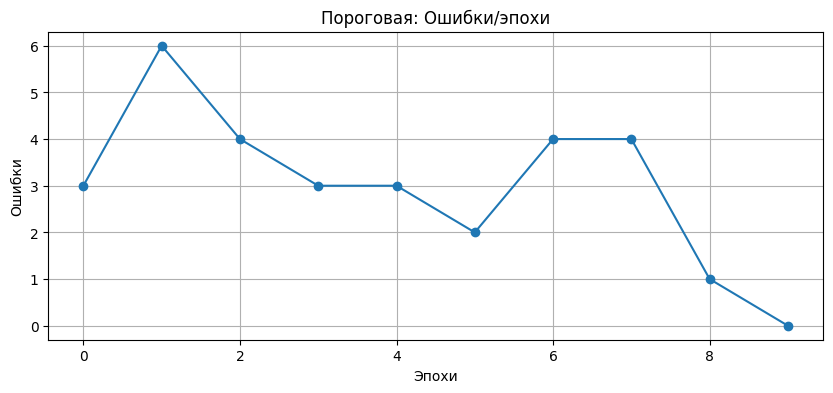


--- Сигмоид ---
Epoch 0: Weights = [-0.748372770969044, -0.2932887922291074, -0.6198164885041073, -0.722632946694371, -0.48274129730004545], Total Error = 3
Epoch 1: Weights = [-0.788613785262505, -0.41835034175684305, -1.0068633262272033, -1.1170710511812838, -0.6171914374128729], Total Error = 3
Epoch 2: Weights = [-0.7132016114359507, -0.4966510216489056, -1.3346147115427343, -1.4478458016856395, -0.6953728938675869], Total Error = 3
Epoch 3: Weights = [-0.5909931785959408, -0.5541832021412257, -1.6309752469898795, -1.7458037924823775, -0.7496574456691082], Total Error = 3
Epoch 4: Weights = [-0.44884039794016617, -0.6015679330517335, -1.9066678823438563, -2.022403423286387, -0.7921384166377591], Total Error = 3
Epoch 5: Weights = [-0.3008375646882174, -0.6441239538060856, -2.166921211690298, -2.2831543127545952, -0.8286269260800804], Total Error = 3
Epoch 6: Weights = [-0.15561717222372007, -0.684639956394521, -2.4145982679878806, -2.531053266888237, -0.8621122550996096], Total Er

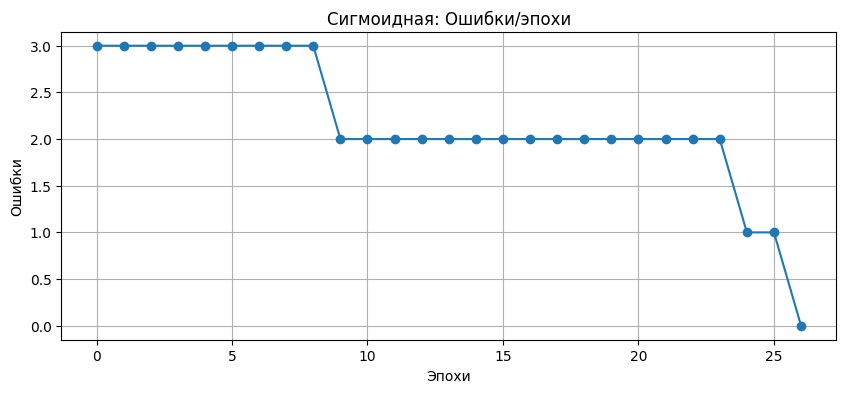

In [ ]:
import matplotlib.pyplot as plt

def boolean_function(x1, x2, x3, x4):
    part1 = x1 or x2 or x3
    part2 = x2 or x3 or x4
    return int(not (part1 and part2))

def generate_dataset():
    dataset = []
    for x1 in (0, 1):
        for x2 in (0, 1):
            for x3 in (0, 1):
                for x4 in (0, 1):
                    x = [1.0, float(x1), float(x2), float(x3), float(x4)]
                    t = boolean_function(x1, x2, x3, x4)
                    dataset.append((x, t))
    return dataset

class Perceptron:
    def __init__(self, weights):
        self.w = weights

    def net(self, x):
        return sum(xi * wi for xi, wi in zip(x, self.w))

    def Fnet_threshold(self, net):
        return 1 if net >= 0 else 0

    def Fnet_sigmoid(self, net):
        return 0.5 * (net / (1 + abs(net)) + 1)

    def discretize(self, out):
        return 1 if out >= 0.5 else 0

    def update_weights_threshold(self, x, err, lr):
        for i in range(len(self.w)):
            self.w[i] += lr * err * x[i]

    def update_weights_sigmoid(self, x, err_cont, lr, net):
         for i in range(len(self.w)):
            self.w[i] += lr * err_cont * x[i]

def train_perceptron_threshold(perceptron, dataset, lr, max_epochs):
    epochs_list = []
    errors_list = []

    for epoch in range(max_epochs):
        total_error = 0
        for x, t in dataset:
            net = perceptron.net(x)
            out = perceptron.Fnet_threshold(net)
            err = t - out
            total_error += abs(err)
            perceptron.update_weights_threshold(x, err, lr)

        epochs_list.append(epoch)
        errors_list.append(total_error)
        print(f"Epoch {epoch}: Weights = {perceptron.w}, Total Error = {total_error}")

        if total_error == 0:
            break

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_list, errors_list, marker='o')
    plt.xlabel('Эпохи')
    plt.ylabel('Ошибки')
    plt.title('Пороговая: Ошибки/эпохи')
    plt.grid()
    plt.show()

def train_perceptron_sigmoid(perceptron, dataset, lr, max_epochs):
    epochs_list = []
    errors_list = []

    for epoch in range(max_epochs):
        total_error = 0
        for x, t in dataset:
            net = perceptron.net(x)
            out = perceptron.Fnet_sigmoid(net)
            err_cont = t - out                        
            total_error += abs(t - perceptron.discretize(out))  
            perceptron.update_weights_sigmoid(x, err_cont, lr, net)  # передаём net

        epochs_list.append(epoch)
        errors_list.append(total_error)
        print(f"Epoch {epoch}: Weights = {perceptron.w}, Total Error = {total_error}")

        if total_error == 0:  
            break

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_list, errors_list, marker='o')
    plt.xlabel('Эпохи')
    plt.ylabel('Ошибки')
    plt.title('Сигмоидная: Ошибки/эпохи')
    plt.grid()
    plt.show()

if __name__ == "__main__":
    dataset = generate_dataset()

    print("\n--- Пороговая ---")
    p_thresh = Perceptron([0.0] * 5)
    train_perceptron_threshold(p_thresh, dataset, lr=0.3, max_epochs=100)

    print("\n--- Сигмоид ---")
    p_sigmoid = Perceptron([0.0] * 5)
    train_perceptron_sigmoid(p_sigmoid, dataset, lr=0.3, max_epochs=100)

In [9]:
import pandas as pd

# Создание DataFrame из dataset
data = []
for x, t in dataset:
    row = x + [t]
    data.append(row)

df = pd.DataFrame(data, columns=['x0 (bias)', 'x1', 'x2', 'x3', 'x4', 'Target'])
df = df.drop(columns=['x0 (bias)'])
df = df.applymap(lambda x: 1 if x > 0 else 0)
df

C:\Users\Slyexistence\AppData\Local\Temp\ipykernel_19224\3091061809.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: 1 if x > 0 else 0)


,x1,x2,x3,x4,Target
0,0,0,0,0,1
1,0,0,0,1,1
2,0,0,1,0,0
3,0,0,1,1,0
4,0,1,0,0,0
5,0,1,0,1,0
6,0,1,1,0,0
7,0,1,1,1,0
8,1,0,0,0,1
9,1,0,0,1,0
